# Module 8: Practical Data Analysis and Reporting

### Course: R Programming - A Comprehensive Guide

**Author:** Kajola Gbenga
**Role:** Data Scientist & AI Engineer

---


## Learning Objectives

By the end of this notebook, you will be able to:

- Work through a full analysis using a real-world data set
- Follow a structured data analysis workflow
- Generate reproducible reports with R Markdown
- Apply dashboard and visualization best practices
- Integrate R with Excel and SQL data sources
- Understand the principles of reproducible data analysis

## 1. Working with Real-World Datasets

Real-world data is rarely clean. Working with it well requires patience and a systematic approach: understand the source and context of the data, check data types and ranges, look for missing values, duplicates, and inconsistent categories, and document every transformation you make.

In [1]:
data(mtcars)
df <- mtcars

# Quick real-world checks
anyNA(df)                 # any missing values?
sum(duplicated(df))       # any duplicate rows?
sapply(df, function(x) length(unique(x)))  # unique values per column


[1] FALSE

[1] 0

mpg  cyl disp   hp drat   wt qsec   vs   am gear carb 
  25    3   27   22   22   29   30    2    2    3    6

## 2. Data Analysis Workflow

A typical end to end data analysis workflow in R follows these stages:

1. **Define the question** - what are you trying to find out?
2. **Import** - load the raw data
3. **Tidy and clean** - fix types, handle missing values and outliers
4. **Transform** - create new features, aggregate, filter
5. **Visualize and explore** - understand patterns and relationships
6. **Model** - apply statistical or machine learning methods
7. **Communicate** - report and present findings


Warning message:
"package 'dplyr' was built under R version 4.5.3"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'ggplot2' was built under R version 4.5.3"


cyl,avg_mpg,avg_hp
<fct>,<dbl>,<dbl>
4,26.66364,82.63636
6,19.74286,122.28571
8,15.10000,209.21429


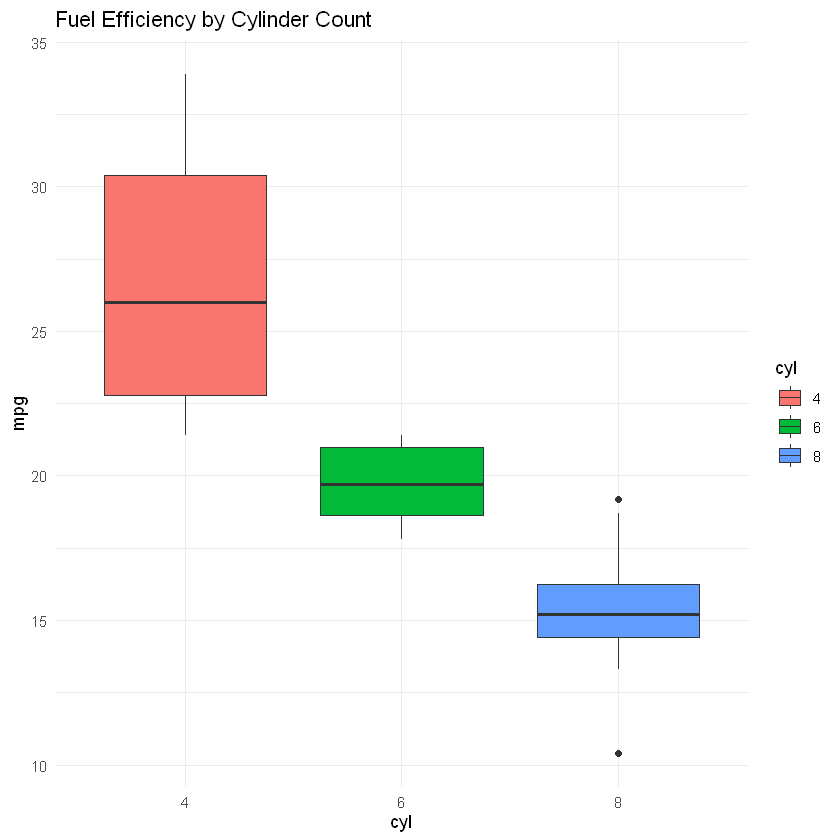

In [2]:
library(dplyr)
library(ggplot2)

# Example workflow applied to mtcars
clean_df <- mtcars %>%
  mutate(cyl = factor(cyl)) %>%
  filter(mpg > 10)

summary_stats <- clean_df %>%
  group_by(cyl) %>%
  summarise(avg_mpg = mean(mpg), avg_hp = mean(hp))
summary_stats

ggplot(clean_df, aes(x = cyl, y = mpg, fill = cyl)) +
  geom_boxplot() +
  labs(title = "Fuel Efficiency by Cylinder Count") +
  theme_minimal()


## 3. Report Generation with R Markdown

R Markdown (`.Rmd`) combines narrative text, R code, and output (tables, plots) into a single reproducible document that can be rendered ("knit") into HTML, PDF, or Word.

A minimal R Markdown file looks like this:

```
---
title: "Sales Analysis Report"
author: "Kajola Gbenga"
date: "`r Sys.Date()`"
output: html_document
---

## Introduction
This report analyzes monthly sales performance.

```{r}
summary(mtcars)
```
```

To render it, run `rmarkdown::render("report.Rmd")` or click **Knit** in RStudio.

In [3]:
# install.packages("rmarkdown")
library(rmarkdown)

# rmarkdown::render("report.Rmd", output_format = "html_document")

cat("R Markdown documents mix code, output, and narrative text in one reproducible file.\n")


Warning message:
"package 'rmarkdown' was built under R version 4.5.3"


R Markdown documents mix code, output, and narrative text in one reproducible file.


## 4. Dashboard and Visualization Best Practices

When building dashboards (e.g. with `flexdashboard` or `shiny`), keep these principles in mind:
- Show the most important metric first
- Use consistent colors and a clean, uncluttered layout
- Choose the right chart type for the data (trend -> line, comparison -> bar, distribution -> histogram)
- Avoid 3D effects, excessive decoration, and unnecessary gridlines
- Label axes and include units
- Make dashboards interactive where useful (filters, drill downs)


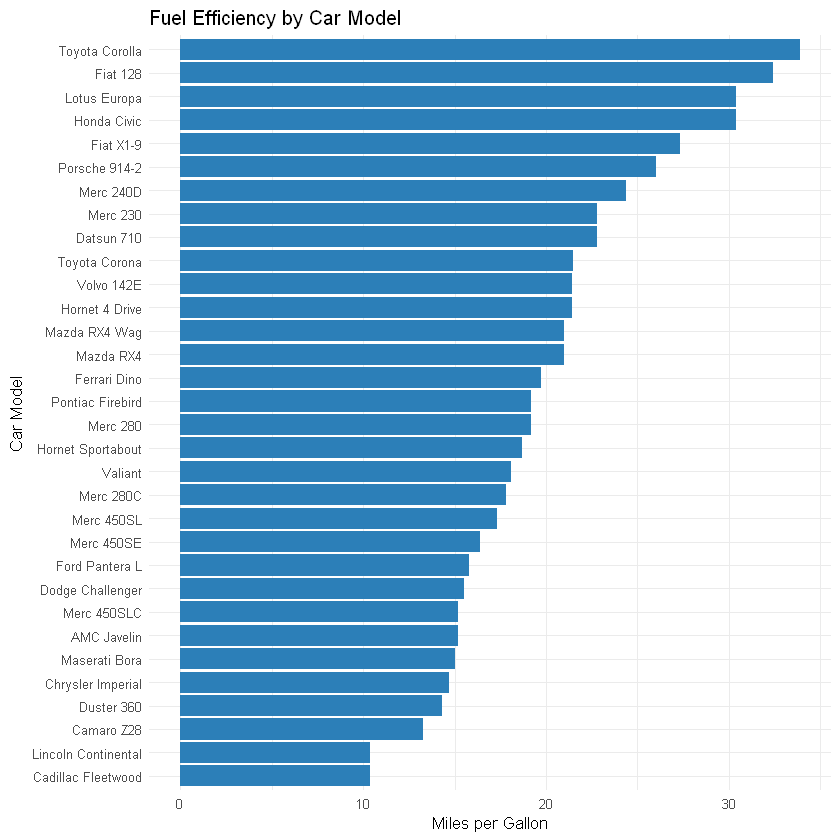

In [4]:
library(ggplot2)

# A clean, well labeled visualization following best practices
ggplot(mtcars, aes(x = reorder(rownames(mtcars), mpg), y = mpg)) +
  geom_col(fill = "#2c7fb8") +
  coord_flip() +
  labs(title = "Fuel Efficiency by Car Model", x = "Car Model", y = "Miles per Gallon") +
  theme_minimal(base_size = 10)


## 5. Integrating R with Excel and SQL

R can read from and write to Excel files, and connect directly to SQL databases for larger data sets that do not fit comfortably in memory.

In [5]:
# ---- R with Excel ----
# library(readxl)
# library(writexl)
# excel_data <- read_excel("report.xlsx", sheet = "Sales")
# write_xlsx(clean_df, "cleaned_report.xlsx")

# ---- R with SQL ----
# install.packages(c("DBI", "RSQLite"))
library(DBI)
library(RSQLite)

# Create an in-memory SQLite database for demonstration
con <- dbConnect(RSQLite::SQLite(), ":memory:")
dbWriteTable(con, "cars", mtcars)

# Run SQL queries directly from R
result <- dbGetQuery(con, "SELECT * FROM cars WHERE cyl = 6")
result

dbDisconnect(con)


Warning message:
"package 'DBI' was built under R version 4.5.3"
Warning message:
"package 'RSQLite' was built under R version 4.5.3"


mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4
17.8,6,167.6,123,3.92,3.440,18.90,1,0,4,4
19.7,6,145.0,175,3.62,2.770,15.50,0,1,5,6


## 6. Reproducible Data Analysis

Reproducibility means anyone (including your future self) can re-run your analysis and get the same results. Best practices:
- Use R Projects to keep files organized in one self contained folder
- Use relative paths, not absolute paths (e.g. `"data/sales.csv"` not `"C:/Users/.../sales.csv"`)
- Set a random seed (`set.seed()`) whenever randomness is involved
- Track package versions with `renv` for consistent environments
- Version control your scripts with Git
- Document every step with comments or R Markdown narrative


In [ ]:
# Example: capturing the full session environment for reproducibility
sessionInfo()

# install.packages("renv")
# renv::init()      # creates a reproducible package environment for a project
# renv::snapshot()  # records exact package versions used


R version 4.5.2 (2025-10-31 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 22000)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=English_Nigeria.utf8  LC_CTYPE=English_Nigeria.utf8   
[3] LC_MONETARY=English_Nigeria.utf8 LC_NUMERIC=C                    
[5] LC_TIME=English_Nigeria.utf8    

time zone: Africa/Lagos
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] RSQLite_3.53.3 DBI_1.3.0      rmarkdown_2.31 ggplot2_4.0.3  dplyr_1.2.1   

loaded via a namespace (and not attached):
 [1] bit_4.6.0          gtable_0.3.6       jsonlite_2.0.0     compiler_4.5.2    
 [5] crayon_1.5.3       tidyselect_1.2.1   IRdisplay_1.1      blob_1.3.0        
 [9] systemfonts_1.3.2  scales_1.4.0       textshaping_1.0.5  uuid_1.2-1        
[13] fastmap_1.2.0      IRkernel_1.3.2     R6_2.6.1           labeling_0.4.3    
[17] generics_0.1.4     knitr_1.

: 

## Practice Exercise

1. Take a real-world data set and run it through the full analysis workflow: import, clean, transform, visualize, and summarize.
2. Write a short R Markdown report that includes at least one table and one chart, then knit it to HTML.
3. Load a data set into a SQLite database from R and run at least two different SQL queries against it.


---

## Module Summary

This notebook has walked through the core concepts, R code demonstrations, and practice exercises for this module. Review each section, run every code cell yourself, and attempt the practice exercises before moving to the next module.

**Kajola Gbenga**
Data Scientist & AI Engineer